# Notebook 01: Depression-Associated Gene Analysis

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook focuses on the exploratory analysis of depression-associated genes.
The purpose of this analysis is to understand the available gene information,
identify important genes based on their association scores, and select potential
candidates for further protein and drug-target analysis.


### Research Workflow

This notebook represents the first stage of the overall research workflow:

1. Analysis of depression-associated genes
2. Protein characterisation and feature extraction
3. Drug-target interaction analysis
4. Machine learning-based prediction
5. Identification of potential drug targets


### Dataset Description

The dataset used in this analysis is:

`depression_genes.csv`

This dataset contains information about genes associated with depression,
including their association scores and available biological annotations.

The dataset is analysed to understand the strength of gene-disease
relationships and identify highly associated genes for further investigation.


### Objectives

The main objectives of this notebook are:

1. To explore and understand the structure of the depression-associated gene dataset.
2. To examine the quality and completeness of the available data.
3. To analyse gene association scores and identify highly ranked genes.
4. To select important candidate genes for further protein-level analysis.
5. To generate processed outputs that can be used in the next stages of the project.

In [31]:
# 1. Import Required Libraries

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


In [32]:
# 2. Set Up Project Directories

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# Define project directories

PROJECT_ROOT = (
    "/content/drive/MyDrive/Dissertation/"
    "Depression-Drug-Target-AI"
)


RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)


PROCESSED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)


FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "figures"
)


print("Project directories configured.")

Project directories configured.


In [34]:
# 3. Load Depression Gene Dataset

file_path = os.path.join(
    RAW_DATA_PATH,
    "depression_genes.csv"
)


genes_df = pd.read_csv(file_path)


print(
    f"Dataset loaded successfully."
)

print(
    f"Number of genes: {genes_df.shape[0]}"
)

print(
    f"Number of features: {genes_df.shape[1]}"
)

Dataset loaded successfully.
Number of genes: 200
Number of features: 5


In [35]:
# 4. Explore Dataset Preview

display(
    genes_df.head()
)

,ensembl_id,gene_symbol,protein_name,biotype,association_score
0,ENSG00000149295,DRD2,dopamine receptor D2,protein_coding,0.746286
1,ENSG00000102468,HTR2A,5-hydroxytryptamine receptor 2A,protein_coding,0.703814
2,ENSG00000022355,GABRA1,gamma-aminobutyric acid type A receptor subuni...,protein_coding,0.682714
3,ENSG00000183454,GRIN2A,glutamate ionotropic receptor NMDA type subuni...,protein_coding,0.669437
4,ENSG00000108576,SLC6A4,solute carrier family 6 member 4,protein_coding,0.645037


In [36]:
# 5. Understand Dataset Structure

genes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ensembl_id         200 non-null    object 
 1   gene_symbol        200 non-null    object 
 2   protein_name       200 non-null    object 
 3   biotype            200 non-null    object 
 4   association_score  200 non-null    float64
dtypes: float64(1), object(4)
memory usage: 7.9+ KB


In [37]:
# 6. Generate Statistical Summary

genes_df.describe(include="all")

,ensembl_id,gene_symbol,protein_name,biotype,association_score
count,200,200,200,200,200.000000
unique,200,200,200,1,NaN
top,ENSG00000149295,DRD2,dopamine receptor D2,protein_coding,NaN
freq,1,1,1,200,NaN
mean,NaN,NaN,NaN,NaN,0.494913
std,NaN,NaN,NaN,NaN,0.084745
min,NaN,NaN,NaN,NaN,0.378568
25%,NaN,NaN,NaN,NaN,0.416221
50%,NaN,NaN,NaN,NaN,0.480191
75%,NaN,NaN,NaN,NaN,0.578019


In [38]:
# 7. Assess Data Quality

missing_values = (
    genes_df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_values

,0
ensembl_id,0
gene_symbol,0
protein_name,0
biotype,0
association_score,0


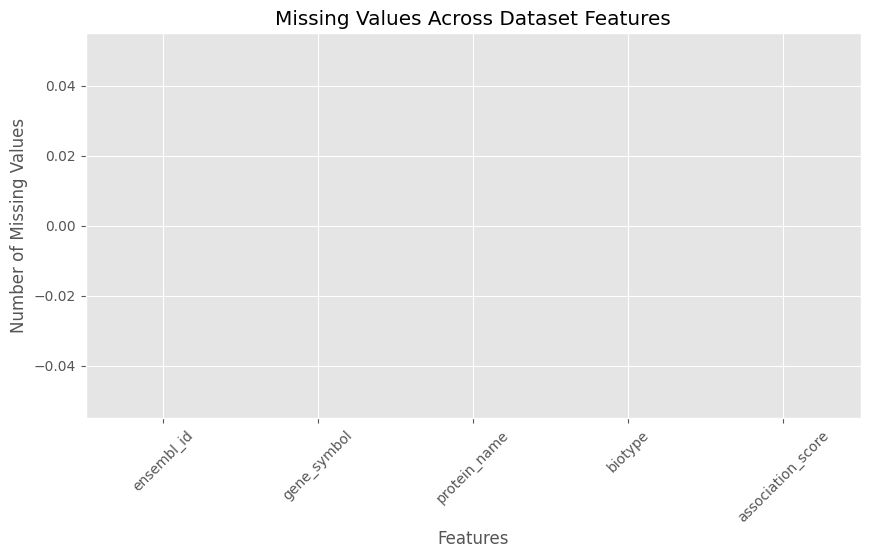

In [39]:
# 8. Visualise Missing Data

plt.figure(figsize=(10,5))

missing_values.plot(
    kind="bar"
)

plt.title(
    "Missing Values Across Dataset Features"
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Number of Missing Values"
)

plt.xticks(rotation=45)

plt.show()

In [40]:
# 9. Check Duplicate Records

duplicate_count = genes_df.duplicated().sum()

print(
    f"Duplicate rows: {duplicate_count}"
)

Duplicate rows: 0


In [41]:
# 10. Analyse Gene Association Scores

genes_ranked = (
    genes_df
    .sort_values(
        by="association_score",
        ascending=False
    )
)


genes_ranked.head(20)

,ensembl_id,gene_symbol,protein_name,biotype,association_score
0,ENSG00000149295,DRD2,dopamine receptor D2,protein_coding,0.746286
1,ENSG00000102468,HTR2A,5-hydroxytryptamine receptor 2A,protein_coding,0.703814
2,ENSG00000022355,GABRA1,gamma-aminobutyric acid type A receptor subuni...,protein_coding,0.682714
3,ENSG00000183454,GRIN2A,glutamate ionotropic receptor NMDA type subuni...,protein_coding,0.669437
4,ENSG00000108576,SLC6A4,solute carrier family 6 member 4,protein_coding,0.645037
5,ENSG00000178394,HTR1A,5-hydroxytryptamine receptor 1A,protein_coding,0.637050
6,ENSG00000142319,SLC6A3,solute carrier family 6 member 3,protein_coding,0.629643
7,ENSG00000151577,DRD3,dopamine receptor D3,protein_coding,0.624555
8,ENSG00000113327,GABRG2,gamma-aminobutyric acid type A receptor subuni...,protein_coding,0.622931
9,ENSG00000103546,SLC6A2,solute carrier family 6 member 2,protein_coding,0.621016


In [42]:
# 11. Identify Top 20 Depression-Associated Genes

top20_genes = (
    genes_ranked
    .head(20)
)


display(top20_genes)

,ensembl_id,gene_symbol,protein_name,biotype,association_score
0,ENSG00000149295,DRD2,dopamine receptor D2,protein_coding,0.746286
1,ENSG00000102468,HTR2A,5-hydroxytryptamine receptor 2A,protein_coding,0.703814
2,ENSG00000022355,GABRA1,gamma-aminobutyric acid type A receptor subuni...,protein_coding,0.682714
3,ENSG00000183454,GRIN2A,glutamate ionotropic receptor NMDA type subuni...,protein_coding,0.669437
4,ENSG00000108576,SLC6A4,solute carrier family 6 member 4,protein_coding,0.645037
5,ENSG00000178394,HTR1A,5-hydroxytryptamine receptor 1A,protein_coding,0.637050
6,ENSG00000142319,SLC6A3,solute carrier family 6 member 3,protein_coding,0.629643
7,ENSG00000151577,DRD3,dopamine receptor D3,protein_coding,0.624555
8,ENSG00000113327,GABRG2,gamma-aminobutyric acid type A receptor subuni...,protein_coding,0.622931
9,ENSG00000103546,SLC6A2,solute carrier family 6 member 2,protein_coding,0.621016


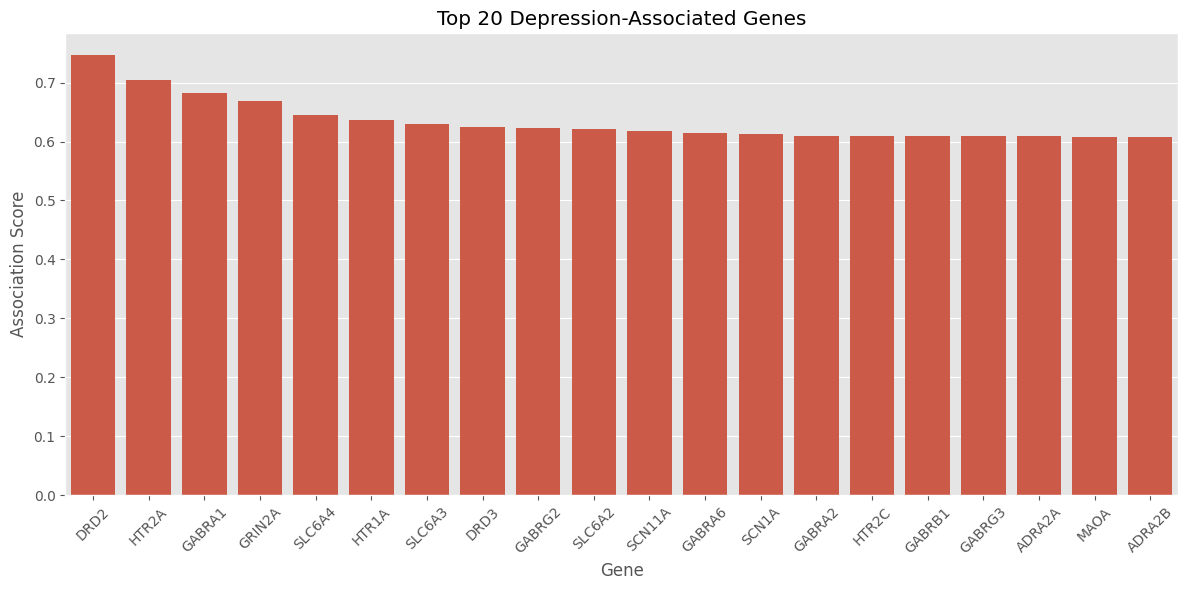

In [43]:
# 12. Visualise Top 20 Depression-Associated Genes

plt.figure(figsize=(12,6))


sns.barplot(
    data=top20_genes,
    x="gene_symbol",
    y="association_score"
)


plt.title(
    "Top 20 Depression-Associated Genes"
)


plt.xlabel(
    "Gene"
)


plt.ylabel(
    "Association Score"
)


plt.xticks(
    rotation=45
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "top20_depression_genes.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [44]:
# 13. Save Processed Results

output_file = os.path.join(
    PROCESSED_DATA_PATH,
    "top20_depression_genes.csv"
)


top20_genes.to_csv(
    output_file,
    index=False
)


print(
    "Processed gene dataset saved."
)

Processed gene dataset saved.


In [45]:
# 14. Download Processed Dataset

from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary of Findings

This notebook analysed the depression-associated gene dataset and identified
the genes with the highest association scores.

The selected genes provide a list of potential candidates for further analysis,
including protein characterisation, structural investigation, and drug-target
interaction analysis.

The processed gene information generated from this analysis will be used as
input for the following stage of the project, where the corresponding proteins
will be studied in more detail.